### Import and process technology cost data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pypsa

In [2]:

# -----------------------------
# Settings
# -----------------------------
country = "DNK"
tech_year = 2025

# -----------------------------
# 1. Import technology costs like course notebook
# -----------------------------
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_{tech_year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]

def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

ann = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]
costs["capital_cost"] = (ann + costs["FOM"] / 100) * costs["investment"]

techs = costs.loc[["solar", "onwind", "offwind", "OCGT"], ["capital_cost", "marginal_cost", "efficiency", "lifetime"]]
display(techs)

parameter,capital_cost,marginal_cost,efficiency,lifetime
technology,,,,
solar,63114.923985,0.010600,1.000,37.5
onwind,107441.457021,1.508000,1.000,28.5
offwind,184567.393550,0.021200,1.000,30.0
OCGT,48739.697513,65.423728,0.405,25.0


### Importing data

In [3]:
df = pd.read_csv(r"data\GenerationProdTypeExchange.csv", sep=";", decimal=",", low_memory=False)
df["TimeDK"] = pd.to_datetime(df["TimeDK"])
df = df.set_index("TimeDK")

cols = ["GrossCon","OffshoreWindPower","OnshoreWindPower","SolarPower"]
df_sorted = df[cols]
df_sorted = df_sorted.groupby(df.index.floor("h")).sum()

df_cap = df_sorted["SolarPower"].max()

cf = pd.DataFrame({
    "solar": df_sorted["SolarPower"]/ df_sorted["SolarPower"].max(),
    "onwind": df_sorted["OnshoreWindPower"] / df_sorted["OnshoreWindPower"].max(),
    "offwind": df_sorted["OffshoreWindPower"] / df_sorted["OffshoreWindPower"].max(),
    "demand": df_sorted["GrossCon"],
}).fillna(0.0)


### Model optimization

In [4]:

# -----------------------------
# 3. Build the PyPSA model
# -----------------------------

#years = [2025] # use if only for 1 year
years = cf.index.year.unique()
print(years)
results = {}

for year in years:
    print(f"For year {year}")
    
    

    cf_year = cf[cf.index.year == year].copy()
    
    cf_year["solar"] /= cf_year["solar"].max()
    cf_year["onwind"] /= cf_year["onwind"].max()
    cf_year["offwind"] /= cf_year["offwind"].max()

    
    n = pypsa.Network()
    n.set_snapshots(cf_year.index)
    
    for carrier in ["electricity", "solar", "onwind", "offwind", "gas", "load_shedding"]:
        n.add("Carrier", carrier)


    n.add("Bus", "electricity", carrier="electricity")
    n.add("Load", "demand", bus="electricity", p_set=cf_year["demand"])

    n.add(
        "Generator",
        "solar",
        bus="electricity",
        carrier="solar",
        p_nom_extendable=True,
        p_max_pu=cf_year["solar"],
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
    )

    n.add(
        "Generator",
        "onwind",
        bus="electricity",
        carrier="onwind",
        p_nom_extendable=True,
        p_max_pu=cf_year["onwind"],
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
    )

    n.add(
        "Generator",
        "offwind",
        bus="electricity",
        carrier="offwind",
        p_nom_extendable=True,
        p_max_pu=cf_year["offwind"],
        capital_cost=costs.at["offwind", "capital_cost"],
        marginal_cost=costs.at["offwind", "marginal_cost"],
    )

    n.add(
        "Generator",
        "OCGT",
        bus="electricity",
        carrier="gas",
        p_nom_extendable=True,
        capital_cost=costs.at["OCGT", "capital_cost"],
        marginal_cost=costs.at["OCGT", "marginal_cost"],
    )

    n.add(
        "Generator",
        "load_shedding",
        bus="electricity",
        carrier="load_shedding",
        p_nom=float(cf_year["demand"].max()),
        marginal_cost=10_000,
    )

    n.optimize(solver_name="highs")
    
    results[year] = n

Index([2020, 2021, 2022, 2023, 2024, 2025], dtype='int32', name='TimeDK')
For year 2020


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 26.07it/s]
INFO:linopy.io: Writing time: 0.59s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 43919 primals, 96617 duals
Objective: 2.35e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


For year 2021


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 24.73it/s]
INFO:linopy.io: Writing time: 0.59s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 43799 primals, 96353 duals
Objective: 2.40e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


For year 2022


...

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 24.33it/s]
INFO:linopy.io: Writing time: 0.58s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 43799 primals, 96353 duals
Objective: 2.42e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


For year 2024


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 24.81it/s]
INFO:linopy.io: Writing time: 0.58s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 43919 primals, 96617 duals
Objective: 2.37e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


For year 2025


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 24.75it/s]
INFO:linopy.io: Writing time: 0.59s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 43799 primals, 96353 duals
Objective: 2.50e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


#### Plots

Optimal capacities (MW)
Generator
solar      3463.75
onwind     7529.51
offwind      -0.00
OCGT       5685.41
Name: p_nom_opt, dtype: float64

Annual generation (GWh)
Generator
solar       4078.45
onwind     17540.18
offwind        0.00
OCGT       17847.65
dtype: float64

Capacity factors
Generator
solar      0.134
onwind     0.266
offwind    0.000
OCGT       0.358
dtype: float64


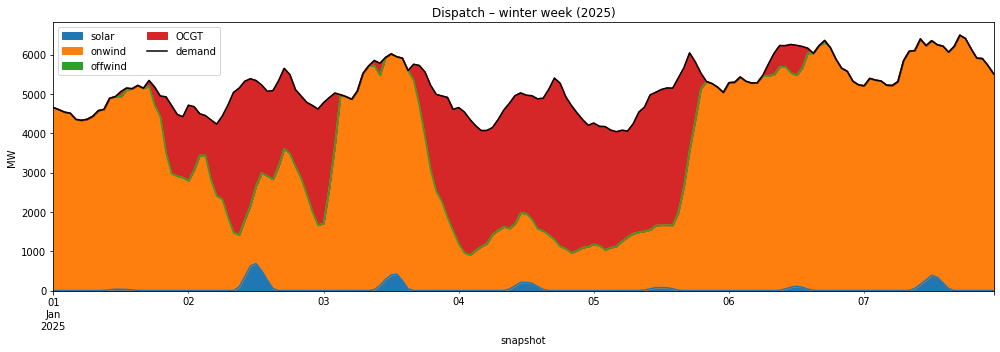

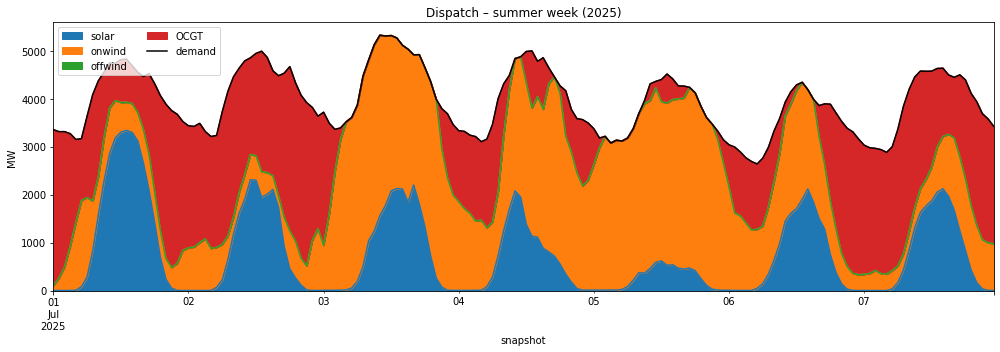

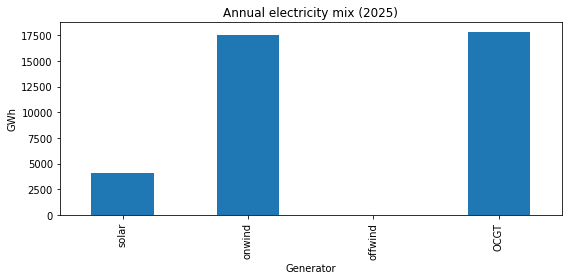

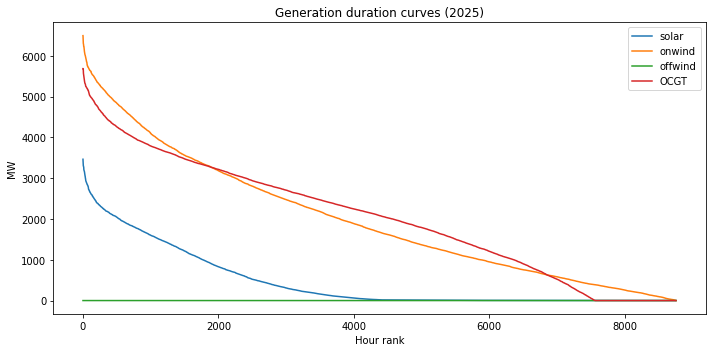

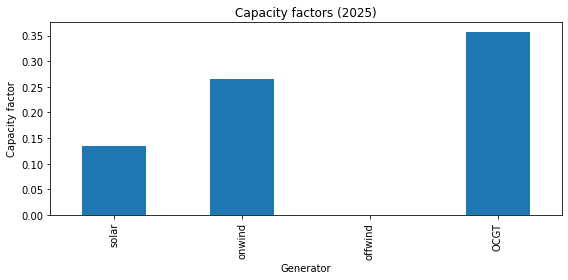

In [5]:
# -----------------------------
# 4. Plot dispatch, annual electricity mix, and duration curves
# -----------------------------
dispatch = n.generators_t.p.copy()

# Exclude load shedding
dispatch_plot = dispatch.drop(columns="load_shedding", errors="ignore")

# Annual generation in GWh
annual_generation = (dispatch_plot.sum() / 1000).round(2)

# Capacity factors
capacities = n.generators["p_nom_opt"].drop("load_shedding", errors="ignore")
capacity_factors = (
    dispatch_plot.sum() / (capacities * len(n.snapshots))
).fillna(0).round(3)

print("Optimal capacities (MW)")
print(capacities.round(2))

print("\nAnnual generation (GWh)")
print(annual_generation)

print("\nCapacity factors")
print(capacity_factors)


def plot_dispatch(dispatch_df, demand_series, title):
    fig, ax = plt.subplots(figsize=(14, 5))
    dispatch_df.plot.area(ax=ax)
    demand_series.plot(ax=ax, color="black", linewidth=1.5, label="demand")
    ax.set_ylabel("MW")
    ax.set_title(title)
    ax.legend(loc="upper left", ncol=2)
    plt.tight_layout()
    plt.show()


year = n.snapshots[0].year

demand_series = n.loads_t.p["demand"]

# -----------------------------
# 1) Winter week dispatch
# -----------------------------
winter = dispatch_plot.loc[f"{year}-01-01":f"{year}-01-07 23:00"]

plot_dispatch(
    winter,
    demand_series.loc[winter.index],
    f"Dispatch – winter week ({year})"
)

# -----------------------------
# 2) Summer week dispatch
# -----------------------------
summer = dispatch_plot.loc[f"{year}-07-01":f"{year}-07-07 23:00"]

plot_dispatch(
    summer,
    demand_series.loc[summer.index],
    f"Dispatch – summer week ({year})"
)

# -----------------------------
# 3) Annual electricity mix
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 4))
annual_generation.plot(kind="bar", ax=ax)
ax.set_ylabel("GWh")
ax.set_title(f"Annual electricity mix ({year})")
plt.tight_layout()
plt.show()

# -----------------------------
# 4) Duration curves
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5))
for col in dispatch_plot.columns:
    dispatch_plot[col].sort_values(ascending=False).reset_index(drop=True).plot(ax=ax, label=col)

ax.set_xlabel("Hour rank")
ax.set_ylabel("MW")
ax.set_title(f"Generation duration curves ({year})")
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 5) Capacity factor bar chart
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 4))
capacity_factors.plot(kind="bar", ax=ax)
ax.set_ylabel("Capacity factor")
ax.set_title(f"Capacity factors ({year})")
plt.tight_layout()
plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


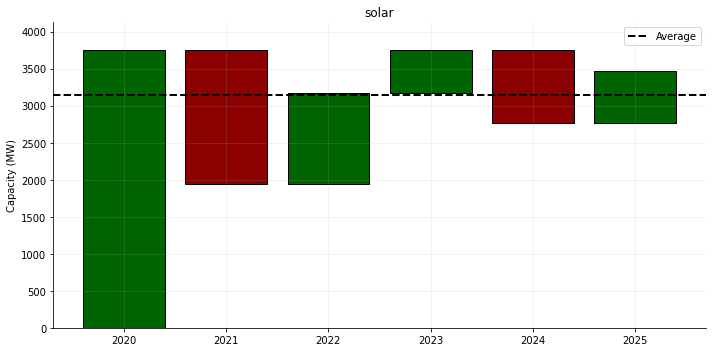

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


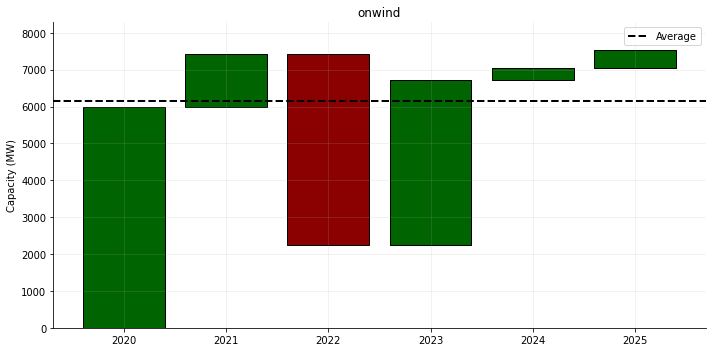

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


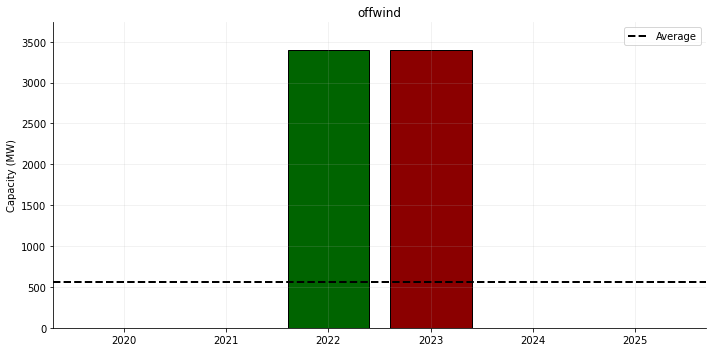

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


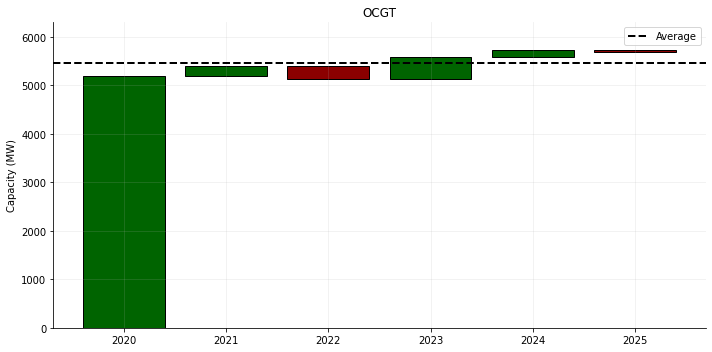

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


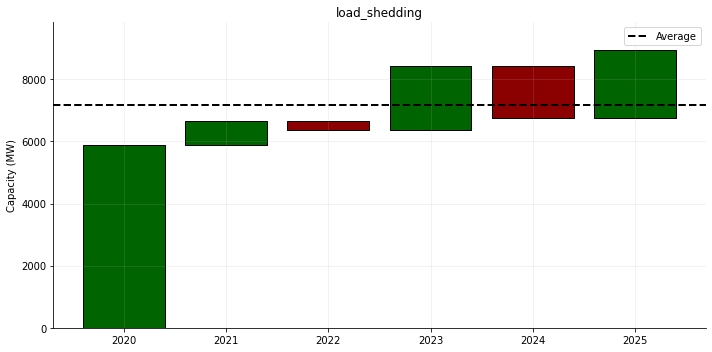

In [6]:
capacity_df = pd.DataFrame({
    year: n.generators.p_nom_opt
    for year, n in results.items()
}).T

def plot_waterfall(data, tech_name, avg_value):
    years = data.index.astype(str)
    values = data.values

    # Year-to-year changes
    deltas = np.diff(values, prepend=0)
    deltas[0] = values[0]
    colors = ['darkgreen' if val >= 0 else 'darkred' for val in deltas]

    bottoms = np.cumsum(np.insert(deltas[:-1], 0, 0))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(years, deltas, bottom=bottoms, color=colors, edgecolor="black")
    ax.axhline(avg_value, color="black", linestyle="--", linewidth=2,
               label=f"Average")
    ax.set_title(f"{tech_name}")
    ax.set_ylabel("Capacity (MW)")
    ax.grid(alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')
    ax.legend()
    
    
    plt.xticks(rotation=0)
    plt.ylim(0, values.max() * 1.1)
    plt.tight_layout()
    plt.show()


for tech in capacity_df.columns:
    series = capacity_df[tech]
    avg = series.mean()
    plot_waterfall(series, tech, avg)